# DOUBLE POST LASSO - FRANCE GENDER WAGE GAP DATA

By Vladislava Anashkina

This code follows closely the analysis of the paper "Closing the U.S. gender wage gap requires understanding its heterogeneity" by Philipp Bach, Victor Chernozhukov, Martin Spindler (https://arxiv.org/abs/1812.04345). 

Google colab: https://colab.research.google.com/github/CausalAIBook/MetricsMLNotebooks/blob/main/PM2/python_heterogeneous_wage_effects.ipynb#scrollTo=OBmzPIRZ__ks 

## Setup

Load the required libraries:

In [1]:
import pandas as pd
import os
import numpy as np
from sklearn.linear_model import LinearRegression
from scipy.stats import norm
import patsy
import warnings
warnings.simplefilter("ignore")
np.random.seed(1234)

### Load the data

In [2]:
df = pd.read_csv("sample_dataset (1).txt")

In [3]:
print(df.columns)

Index(['A6', 'A17', 'A38', 'CPFD', 'DATDEB', 'DATFIN', 'DEPR', 'DEPT',
       'DOMEMPL', 'DOMEMPL_EM', 'DUREE', 'FILT', 'REGR', 'REGT', 'SEXE', 'PCS',
       'TYP_EMPLOI', 'CONV_COLL', 'NBHEUR', 'NBHEUR_TOT', 'AGE', 'TRNNETO',
       'TRALCHT', 'TREFF', 'CONT_TRAV', 'CS', 'AGE_TR', 'DATDEB_TR',
       'DATFIN_TR', 'DUREE_TR', 'POND', 'annual_wage_euro', 'y', 'female'],
      dtype='object')


# Define outcome & base dataframe

Cleaning income threshold

In [4]:
# Copy data
df_clean = df.copy()

# Keep only observations below the income cutoff 
df_clean = df_clean[df_clean["y"] < 10.3889953683178].copy()

# Reset index
df_clean = df_clean.reset_index(drop=True)

print(df.shape, "->", df_clean.shape)

(762661, 34) -> (463882, 34)


In [5]:
y = df_clean["y"].astype(float).values
Z = df_clean.drop(columns=["y", "annual_wage_euro"]).copy()

cat_cols = [
    "A6", "A17", "A38", "CPFD", "DEPR", "DEPT",
    "DOMEMPL", "DOMEMPL_EM", "FILT", "REGR", "REGT",
    "SEXE", "PCS", "TYP_EMPLOI", "CONV_COLL",
    "TRNNETO", "TRALCHT", "CONT_TRAV", "CS",
    "AGE_TR", "DATDEB_TR", "DATFIN_TR", "DUREE_TR", "TREFF"
]

for c in cat_cols:
    if c in Z.columns:
        Z[c] = Z[c].astype("category")

Z["female"] = Z["female"].astype(float)

## Diagnostics: Age, Contract Duration & Occupational Category
*Visual checks on key continuous and categorical covariates before modelling.*

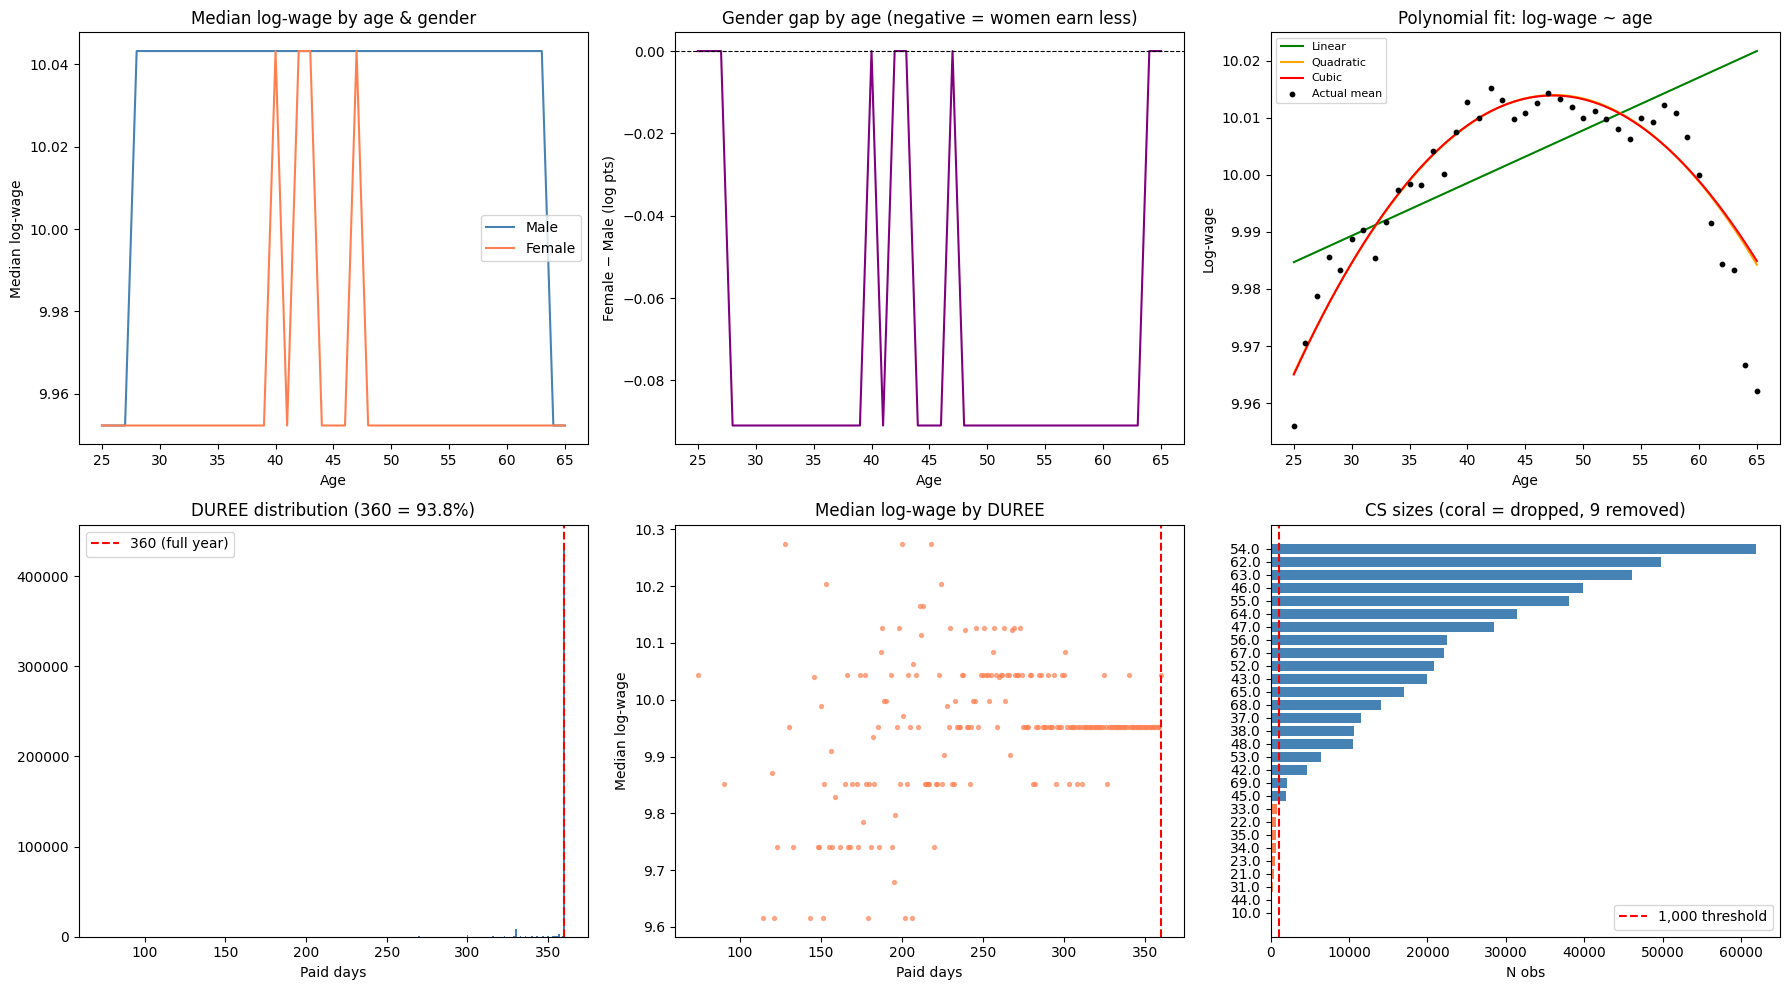

In [6]:
# ── Diagnostics: AGE, DUREE, CS ──────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

cs_counts = df_clean["CS"].value_counts().sort_values()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Median log-wage by age & gender
age_gap = df_clean.groupby(["AGE", "female"])["y"].median().unstack()
age_gap.columns = ["male", "female"]
axes[0,0].plot(age_gap.index, age_gap["male"],   color="steelblue", label="Male")
axes[0,0].plot(age_gap.index, age_gap["female"], color="coral",     label="Female")
axes[0,0].set(title="Median log-wage by age & gender", xlabel="Age", ylabel="Median log-wage")
axes[0,0].legend()

# 2. Gender gap across lifecycle
age_gap["gap"] = age_gap["female"] - age_gap["male"]
axes[0,1].plot(age_gap.index, age_gap["gap"], color="purple")
axes[0,1].axhline(0, color="black", lw=0.8, ls="--")
axes[0,1].set(title="Gender gap by age (negative = women earn less)", xlabel="Age", ylabel="Female − Male (log pts)")

# 3. Polynomial fit justification
age_grid = np.linspace(25, 65, 200)
ages, wages = df_clean["AGE"].astype(float).values, df_clean["y"].astype(float).values
for deg, col, lbl in [(1,"green","Linear"), (2,"orange","Quadratic"), (3,"red","Cubic")]:
    axes[0,2].plot(age_grid, np.polyval(np.polyfit(ages, wages, deg), age_grid), color=col, label=lbl)
axes[0,2].scatter(*zip(*df_clean.groupby("AGE")["y"].mean().items()), color="black", s=10, zorder=5, label="Actual mean")
axes[0,2].set(title="Polynomial fit: log-wage ~ age", xlabel="Age", ylabel="Log-wage")
axes[0,2].legend(fontsize=8)

# 4. DUREE distribution
d = df_clean["DUREE"].value_counts().sort_index()
axes[1,0].bar(d.index, d.values, color="steelblue", width=1.0)
axes[1,0].axvline(360, color="red", ls="--", label="360 (full year)")
axes[1,0].set(title=f"DUREE distribution (360 = {(df_clean['DUREE']==360).mean():.1%})", xlabel="Paid days")
axes[1,0].legend()

# 5. Wage vs paid days
dw = df_clean.groupby("DUREE")["y"].median()
axes[1,1].scatter(dw.index, dw.values, color="coral", s=8, alpha=0.6)
axes[1,1].axvline(360, color="red", ls="--")
axes[1,1].set(title="Median log-wage by DUREE", xlabel="Paid days", ylabel="Median log-wage")

# 6. CS category sizes
axes[1,2].barh(cs_counts.index.astype(str), cs_counts.values,
               color=["coral" if v < 1000 else "steelblue" for v in cs_counts.values])
axes[1,2].axvline(1000, color="red", ls="--", label="1,000 threshold")
axes[1,2].set(title=f"CS sizes (coral = dropped, {(cs_counts < 1000).sum()} removed)", xlabel="N obs")
axes[1,2].legend()

plt.tight_layout()
plt.show()

> **Diagnostics summary:** The age/gender plots show vertical spikes due to an odd/even alternation in
> sample counts (odd ages have ~3× more observations than even ones) — a survey design artefact, not a data
> error. The quadratic fit (top-right) tracks actual means best. `DUREE` is heavily right-censored at 360
> days (93.8%). CS looks fine with 9 sparse categories dropped.

## Preprocessing & Feature Engineering
*Drops 9 rare CS categories (<1k obs, 0.9% of rows), encodes `DUREE` as a full-year binary, and expands
`AGE` into a scaled cubic polynomial. Output: 459k rows, 0 nulls, ready for modelling.*

In [7]:
# ── Preprocessing ─────────────────────────────────────────────────────────────

# 1. Filter rare CS categories (≥1,000 obs)
cs_counts = df_clean["CS"].value_counts()
valid_cs  = cs_counts[cs_counts >= 1000].index
df_model  = df_clean[df_clean["CS"].isin(valid_cs)].copy()
print(f"CS trim: dropped {(~df_clean['CS'].isin(valid_cs)).sum()} rows "
      f"({(~df_clean['CS'].isin(valid_cs)).mean():.1%}) — "
      f"{df_model['CS'].nunique()} categories kept")

# 2. Drop unused columns
df_model = df_model.drop(columns=["DOMEMPL", "DOMEMPL_clean", "A38"], errors="ignore")

# 3. DUREE → binary full_year
df_model["full_year"] = (df_model["DUREE"] == 360).astype(float)

# 4. AGE → cubic polynomial (scaled)
vals = df_model["AGE"].astype(float)
df_model["AGE1"] = vals
df_model["AGE2"] = vals**2 / 100
df_model["AGE3"] = vals**3 / 1000

# 5. NBHEUR → float
df_model["NBHEUR1"] = df_model["NBHEUR"].astype(float)

# 6. Categorical types
for col in ["A6", "CS", "CONT_TRAV", "REGR"]:
    df_model[col] = df_model[col].astype("category")
df_model["female"] = df_model["female"].astype(float)

# 7. Alias
dm = df_model.copy()

# ── Sanity check ──────────────────────────────────────────────────────────────
print(f"Shape: {dm.shape} | Nulls: {dm.isnull().sum().sum()}")
print(f"full_year=1: {dm['full_year'].mean():.1%} | female=1: {dm['female'].mean():.1%}")
print(f"CS cats: {dm['CS'].nunique()} | AGE1: [{dm['AGE1'].min():.0f}, {dm['AGE1'].max():.0f}]")

CS trim: dropped 4165 rows (0.9%) — 20 categories kept
Shape: (459717, 37) | Nulls: 0
full_year=1: 93.8% | female=1: 42.5%
CS cats: 20 | AGE1: [25, 65]


## Variable Decisions & Model Dimensionality
*Sets reference categories for all categorical variables and counts the total number of regressors before estimation.*

In [8]:
# ── Variable decisions ────────────────────────────────────────────────────────
# A6: set GI (largest sector, 31.1%) as baseline
dm["A6"] = pd.Categorical(
    dm["A6"].astype(str),
    categories=["GI", "AZ", "BE", "FZ", "JU", "OQ"],
    ordered=False
)

# ── Sanity check ──────────────────────────────────────────────────────────────
cat_vars = {"A6": "GI", "CS": "54.0", "CONT_TRAV": "CDI", "REGR": "11.0"}
for var, baseline in cat_vars.items():
    print(f"{var:12s}: {dm[var].nunique()} categories (baseline = {baseline})")

dummies    = sum(dm[v].nunique() - 1 for v in cat_vars)
continuous = 5  # AGE1, AGE2, AGE3, NBHEUR1, full_year
p1         = dummies + continuous
print(f"\np1 = {p1} ({dummies} dummies + {continuous} continuous)")
print(f"Approx. total columns with interactions: ~{p1 + 1 + p1 + p1*(p1-1)//2}")
print(f"Nulls: {dm.isnull().sum().sum()} | Sample: {len(dm):,}")

A6          : 6 categories (baseline = GI)
CS          : 20 categories (baseline = 54.0)
CONT_TRAV   : 2 categories (baseline = CDI)
REGR        : 18 categories (baseline = 11.0)

p1 = 47 (42 dummies + 5 continuous)
Approx. total columns with interactions: ~1176
Nulls: 0 | Sample: 459,717


## Variable Selection

### A6 ✅ — 5 dummies (baseline = GI)
Broad sector classification (6 categories). GI (Trade/Transport/Hospitality) 
set as baseline — largest sector at 31.1% of sample. A38 dropped: 35 categories 
cause memory failures (~1,895 design matrix columns); acknowledged limitation.

### CS ✅ — 19 dummies (baseline = 54.0)
Socio-professional category (20 categories after rare-category trim ≥1,000 obs). 
Baseline = 54.0 (Employés administratifs d'entreprise) — largest CS group.

### CONT_TRAV ✅ — 1 dummy (baseline = CDI)
Contract type. Two categories remaining after cleaning. 
CDI (permanent contract) as baseline — standard employment reference.

### REGR ✅ — 17 dummies (baseline = 11.0)
Region of residence (18 categories). Baseline = 11.0 (Île-de-France) — 
largest region and highest-wage reference, standard in French wage regressions.

### DOMEMPL ❌ — Dropped
Sparse category (1.0: 1,689 obs vs 9.0: 383k). Redundant with A6 + CS 
which already capture public/private wage differences.

## Model Matrix Construction
*Builds the full design matrix for a high-dimensional OLS with heterogeneous treatment effects.*

The matrix stacks three blocks: **(1)** 47 base regressors (cubic age polynomial, hours, full-year dummy,
and dummies for sector, occupation, contract type, and region); **(2)** 48 target columns (`female` and its
interaction with every base regressor, to flexibly estimate the gender gap); **(3)** 415 pairwise nuisance
interactions between base regressors (low-variance pairs with std < 0.05 are dropped to keep the matrix
sparse). The final matrix is **459k × 510** (~1.88 GB), with no missing values — ready for Lasso/double-ML
selection.

In [9]:
# ── Model Matrix Construction ─────────────────────────────────────────────────
from itertools import combinations
import numpy as np
import pandas as pd

# ── 1. Set baseline categories ────────────────────────────────────────────────
dm["CONT_TRAV"] = pd.Categorical(dm["CONT_TRAV"], categories=["CDI", "CDD"], ordered=False)
dm["CS"]        = pd.Categorical(
    dm["CS"],
    categories=[54.0, 37.0, 38.0, 42.0, 43.0, 45.0, 46.0, 47.0, 48.0,
                52.0, 53.0, 55.0, 56.0, 62.0, 63.0, 64.0, 65.0, 67.0, 68.0, 69.0],
    ordered=False
)
dm["REGR"] = pd.Categorical(
    dm["REGR"],
    categories=[11.0] + [r for r in sorted(dm["REGR"].unique()) if r != 11.0],
    ordered=False
)
# A6 baseline already set to GI ✓

# ── 2. Build dummies ──────────────────────────────────────────────────────────
cont_vars = ["AGE1", "AGE2", "AGE3", "NBHEUR1", "full_year"]
cat_specs = {"A6": "A6", "CS": "CS", "CONT_TRAV": "CONT", "REGR": "REGR"}

dummy_frames = []
for col, prefix in cat_specs.items():
    dummies = pd.get_dummies(dm[col], prefix=prefix, drop_first=True, dtype=float)
    dummy_frames.append(dummies)
    print(f"{col:15s} → {dummies.shape[1]} dummies (baseline = {dm[col].cat.categories[0]})")

X_base = pd.concat([dm[cont_vars].astype(float)] + dummy_frames, axis=1)
x_cols = X_base.columns.tolist()
print(f"\nX_base: {X_base.shape} — {len(x_cols)} base variables (p1)")

# ── 3. Target block: female + female × x_j ───────────────────────────────────
female     = dm["female"].astype(float).values
target_df  = pd.DataFrame(
    {"female": female, **{f"female_X_{c}": female * X_base[c].values for c in x_cols}},
    index=dm.index
)
print(f"Target: {target_df.shape} — {target_df.shape[1]} columns")

# ── 4. Pairwise nuisance interactions ────────────────────────────────────────
print("Building pairwise interactions...")
pair_names, pair_arrays = [], []
for c1, c2 in combinations(x_cols, 2):
    v = X_base[c1].values * X_base[c2].values
    if v.std() > 0.05:
        pair_names.append(f"{c1}_XX_{c2}")
        pair_arrays.append(v)

nuisance_pairs = pd.DataFrame(np.column_stack(pair_arrays), columns=pair_names, index=dm.index)
print(f"Pairs : {len(pair_names)} kept, {len(list(combinations(x_cols,2))) - len(pair_names)} dropped (std < 0.05)")

# ── 5. Final matrix ───────────────────────────────────────────────────────────
X_full      = pd.concat([target_df, X_base, nuisance_pairs], axis=1)
X_full      = X_full.loc[:, ~X_full.columns.duplicated()]
y_vec       = dm["y"].astype(float).values
target_cols = target_df.columns.tolist()  # ['female', 'female_X_AGE1', ...]

print(f"Final matrix : {X_full.shape[0]:,} obs × {X_full.shape[1]:,} cols")
print(f"  target     : {len(target_cols)}  | main: {len(x_cols)}  | pairs: {len(pair_names)}")
print(f"Memory       : {X_full.memory_usage(deep=True).sum()/1e9:.2f} GB | Nulls: {X_full.isnull().sum().sum()}")

A6              → 5 dummies (baseline = GI)
CS              → 19 dummies (baseline = 54.0)
CONT_TRAV       → 1 dummies (baseline = CDI)
REGR            → 17 dummies (baseline = 11.0)

X_base: (459717, 47) — 47 base variables (p1)
Target: (459717, 48) — 48 columns
Building pairwise interactions...
Pairs : 415 kept, 666 dropped (std < 0.05)
Final matrix : 459,717 obs × 510 cols
  target     : 48  | main: 47  | pairs: 415
Memory       : 1.88 GB | Nulls: 0


## Model Matrix Construction

### The Regression Model
$$\ln w_i = \alpha + \beta(x_i) \cdot \text{female}_i + z_i'\delta + \varepsilon_i, \quad \beta(x_i) = \beta_0 + \sum_{j=1}^{47} \beta_j \cdot x_{ij}$$

Following the paper, a **single matrix X** is built and passed to the double lasso, which internally identifies target vs nuisance columns via `target_cols`.

---

### Matrix Contents (510 columns total)
| Block | Columns | Contents |
|---|---|---|
| **Target** | 48 | `female` (β₀) + `female × x_j` for all 47 base variables |
| **Main effects** | 47 | Age polynomial (×3), hours, full-year, sector (A6 ×5), occupation (CS ×19), region (REGR ×17), contract (CONT_TRAV ×1) |
| **Pairwise nuisance** | 415 | x_j × x_k interactions (666 dropped, std < 0.05) |

---

### Base Variables Breakdown (47 columns)
| Group | Variables | Count |
|---|---|---|
| Continuous | `AGE1`, `AGE2`, `AGE3`, `NBHEUR1`, `full_year` | 5 |
| Sector (A6) | AZ, BE, FZ, JU, OQ vs **GI** | 5 |
| Occupation (CS) | 19 categories vs **54.0** | 19 |
| Region (REGR) | 17 regions vs **11.0** | 17 |
| Contract (CONT_TRAV) | CDD vs **CDI** | 1 |

---

### Baseline Categories (the reference man)
| Variable | Baseline | Share |
|---|---|---|
| `A6` | GI (Trade/Transport/Hospitality) | ~31.1% |
| `CS` | 54.0 (Employés administratifs) | ~13.5% |
| `CONT_TRAV` | CDI | ~98% |
| `REGR` | 11.0 (Île-de-France) | ~15.4% |

> **Note on sector classification:** A38 (35 categories) dropped for computational
> feasibility. A6 (6 categories, baseline = GI) used as tractable approximation.
> Within-sector nuisance variation is an acknowledged limitation.

> **Note on pairwise filter:** std < 0.05 drops 666 interactions (415 kept),
> including 198 dummy×dummy pairs (e.g. A6×CS, A6×REGR).
> **Sign convention:** a negative coefficient on `female` or `female_X_*`
> implies women earn less — larger gap.

---

### Interpretation
- **β₀** (`female`): baseline gap for a full-year CDI admin employee (CS 54.0)
  in Île-de-France, Trade/Transport sector (A6 = GI) — negative = women earn less
- **β_BE** (`female_X_A6_BE`): *additional* gap in Manufacturing vs baseline GI —
  total gap in BE = β₀ + β_BE, always vs a comparable man
- **β_AGE1** (`female_X_AGE1`): change in gender gap per additional year of age
- **δ** (nuisance): level wage differences common to both genders — selected by
  lasso but not the object of inference

## Baseline: Raw Gender Wage Gap (No Controls)

Before introducing high-dimensional controls, we estimate the 
**unconditional gender wage gap** via simple OLS with only the 
`female` indicator. This serves as a benchmark — the raw average 
wage difference between men and women in the sample, before 
accounting for occupation, sector, region, or any other characteristic.

In [10]:
import statsmodels.api as sm

# Raw gender wage gap — no controls (benchmark)
X_ols = sm.add_constant(dm["female"].astype(float))
y_ols = dm["y"].astype(float)

model = sm.OLS(y_ols, X_ols).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     6995.
Date:                Sun, 22 Mar 2026   Prob (F-statistic):               0.00
Time:                        10:10:07   Log-Likelihood:             1.2361e+05
No. Observations:              459717   AIC:                        -2.472e+05
Df Residuals:                  459715   BIC:                        -2.472e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.0198      0.000   2.79e+04      0.0

#### Results
The baseline OLS estimates a raw gender wage gap of **−4.6%**
(coef = −0.0461, p < 0.001), meaning women earn on average 4.6%
less than men in log-wage terms, unconditionally.

The very low **R² = 0.015** confirms that gender alone explains
almost none of the wage variation — observable characteristics
(occupation, sector, region, hours, contract type) are essential
controls. This motivates the Double Lasso, which partials out
these confounders to recover the **unexplained** gender wage gap.

# Post-Lasso Estimator Setup

We use `hdmpy`, a Python port of the R package `hdm` (High-Dimensional 
Metrics) by Belloni, Chernozhukov & Hansen, which implements the 
**rigorous Lasso** (`rlasso`) with data-driven penalty selection.

Since `hdmpy` does not natively follow the `sklearn` API, we wrap it 
in a custom `RLasso` class that exposes `.fit()` and `.predict()` 
methods, making it compatible with our Double Lasso pipeline.

We estimate the heterogeneous gender wage effects using the 
**Partialling-Out** procedure of Belloni, Chernozhukov & Hansen (2014), 
implemented via Post-Lasso. For each interaction term 
$D_j = \text{female} \times x_j$, the method proceeds in three steps:

1. **Residualise the outcome:** run Post-Lasso of $y$ on all controls 
   $W$ (all columns except $D_j$) → get $\tilde{Y} = Y - \hat{E}[Y|W]$

2. **Residualise the treatment:** run Post-Lasso of $D_j$ on $W$ → 
   get $\tilde{D}_j = D_j - \hat{E}[D_j|W]$

3. **Final OLS:** regress $\tilde{Y}$ on $\tilde{D}_j$ (no intercept) 
   → the coefficient is $\hat{\beta}_j$

Post-Lasso uses the Lasso for variable selection and then refits OLS on 
the selected variables, removing the shrinkage bias of plain Lasso. The 
partialling-out approach is asymptotically equivalent to double selection 
under regularity conditions (Belloni et al., 2014).

**Inference** is based on the heteroskedasticity-robust sandwich 
covariance matrix:

$$V_{jj} = J_j^{-1} \Sigma_{jj} J_j^{-1}, \quad 
J_j = \mathbb{E}[\tilde{D}_j^2], \quad 
\Sigma_{jj} = \mathbb{E}[\tilde{D}_j^2 \varepsilon_j^2]$$

where $\tilde{D}_j$ is the Post-Lasso residual from projecting $D_j$ on 
$W$, and $\varepsilon_j$ are the final OLS residuals. This gives 
$\sqrt{n}$-consistent, asymptotically normal estimates under approximate 
sparsity (Belloni et al., 2014).

**Sign convention:** a **negative** $\hat{\beta}_j < 0$ means women 
earn **less** than comparable men in that group — a larger wage gap. 
A **positive** $\hat{\beta}_j > 0$ means a smaller or reversed gap.

In [11]:
# ── Install & import hdmpy ────────────────────────────────────────────────────
!pip install multiprocess

In [12]:
!git clone https://github.com/maxhuppertz/hdmpy.git

fatal: destination path 'hdmpy' already exists and is not an empty directory.


In [13]:
import sys
sys.path.insert(1, "./hdmpy")
import hdmpy

In [14]:
import hdmpy
from sklearn.base import BaseEstimator
from sklearn.linear_model import LinearRegression
from scipy.stats import norm

# ── RLasso wrapper ────────────────────────────────────────────────────────────
class RLasso(BaseEstimator):
    def __init__(self, *, post=True):
        self.post = post

    def fit(self, X, y):
        self.rlasso_ = hdmpy.rlasso(np.asarray(X, dtype=float),
                                     np.asarray(y, dtype=float).ravel(),
                                     post=self.post)
        return self

    def predict(self, X):
        beta      = np.asarray(self.rlasso_.est["beta"]).ravel()
        intercept = float(np.asarray(self.rlasso_.est["intercept"]).ravel()[0])
        return np.asarray(X, dtype=float) @ beta + intercept

def lasso_model():
    return RLasso(post=True)

# ── Fixed nuisance block (same for all targets) ───────────────────────────────
nuisance_cols = [c for c in X_full.columns if c not in target_cols]
W_nuisance    = X_full[nuisance_cols].values

# Partial out y once — reused for all targets
print("Partialling out y...")
res_y_base = y_vec - lasso_model().fit(W_nuisance, y_vec).predict(W_nuisance)

# ── Double Post-Lasso loop ────────────────────────────────────────────────────
alpha, res_y, res_D, epsilon = {}, {}, {}, {}

for i, c in enumerate(target_cols):
    print(f"[{i+1}/{len(target_cols)}] {c}")
    D        = X_full[c].values
    res_y[c] = res_y_base.copy()
    res_D[c] = D - lasso_model().fit(W_nuisance, D).predict(W_nuisance)

    final      = LinearRegression(fit_intercept=False).fit(
                     res_D[c].reshape(-1, 1), res_y[c])
    epsilon[c] = res_y[c] - final.predict(res_D[c].reshape(-1, 1))
    alpha[c]   = [final.coef_[0]]

# ── Sandwich covariance ───────────────────────────────────────────────────────
n = X_full.shape[0]
V = np.zeros((len(target_cols), len(target_cols)))
for it, c in enumerate(target_cols):
    Jc = np.mean(res_D[c]**2)
    for itp, cp in enumerate(target_cols):
        Jcp        = np.mean(res_D[cp]**2)
        Sigma      = np.mean(res_D[c] * epsilon[c] * epsilon[cp] * res_D[cp])
        V[it, itp] = Sigma / (Jc * Jcp)

for it, c in enumerate(target_cols):
    alpha[c] += [np.sqrt(V[it, it] / n)]

# ── Summary table ─────────────────────────────────────────────────────────────
df_alpha = pd.DataFrame.from_dict(alpha, orient="index", columns=["point", "stderr"])
summary  = pd.DataFrame({
    "Estimate"   : df_alpha["point"],
    "Std. Error" : df_alpha["stderr"],
    "t-stat"     : df_alpha["point"] / df_alpha["stderr"],
    "p-value"    : norm.sf(np.abs(df_alpha["point"] / df_alpha["stderr"])) * 2,
    "ci_lower"   : df_alpha["point"] - 1.96 * df_alpha["stderr"],
    "ci_upper"   : df_alpha["point"] + 1.96 * df_alpha["stderr"],
})
print(summary)

Partialling out y...
[1/48] female
[2/48] female_X_AGE1
[3/48] female_X_AGE2
[4/48] female_X_AGE3
[5/48] female_X_NBHEUR1
[6/48] female_X_full_year
[7/48] female_X_A6_AZ
[8/48] female_X_A6_BE
[9/48] female_X_A6_FZ
[10/48] female_X_A6_JU
[11/48] female_X_A6_OQ
[12/48] female_X_CS_37.0
[13/48] female_X_CS_38.0
[14/48] female_X_CS_42.0
[15/48] female_X_CS_43.0
[16/48] female_X_CS_45.0
[17/48] female_X_CS_46.0
[18/48] female_X_CS_47.0
[19/48] female_X_CS_48.0
[20/48] female_X_CS_52.0
[21/48] female_X_CS_53.0
[22/48] female_X_CS_55.0
[23/48] female_X_CS_56.0
[24/48] female_X_CS_62.0
[25/48] female_X_CS_63.0
[26/48] female_X_CS_64.0
[27/48] female_X_CS_65.0
[28/48] female_X_CS_67.0
[29/48] female_X_CS_68.0
[30/48] female_X_CS_69.0
[31/48] female_X_CONT_CDD
[32/48] female_X_REGR_1.0
[33/48] female_X_REGR_2.0
[34/48] female_X_REGR_3.0
[35/48] female_X_REGR_4.0
[36/48] female_X_REGR_24.0
[37/48] female_X_REGR_27.0
[38/48] female_X_REGR_28.0
[39/48] female_X_REGR_32.0
[40/48] female_X_REGR_44.0


## Results: Double Post-Lasso — France 2021

**Baseline gap (β₀ = -0.040, p<0.001):** A reference woman (CDI, admin employee
CS 54.0, Île-de-France, A6=GI, full-year) earns **4.0% less** than an equivalent man.

---

### Sector (A6) — Largest Driver of Heterogeneity
| Sector | β_j | Total gap | Sig |
|---|---|---|---|
| Agriculture/Forestry (AZ) | -0.126 | -16.6% | *** |
| Construction (FZ) | -0.060 | -10.0% | *** |
| Manufacturing/Mining (BE) | -0.066 | -10.6% | *** |
| Misc Services (JU) | -0.028 | -6.8% | *** |
| Public Admin/Health (OQ) | +0.007 | -3.3% | *** |

The gap **nearly disappears in public-sector-heavy industries** (OQ) and is
largest in male-dominated sectors — consistent with Goldin (2014).

---

### Occupation (CS) — Strong Heterogeneity
**Largest gaps (most negative β_j, vs baseline CS 54.0):**
- Skilled Industrial Workers CS 62.0: −9.6pp ***
- Retail Employees CS 55.0: −5.5pp ***
- Service Workers CS 56.0: −6.1pp ***
- Supervisors/Foremen CS 48.0: −5.5pp ***
- Unskilled Industrial CS 67.0: −6.9pp ***

**Reduced or reversed gaps:**
- Health/Social Intermediaries CS 43.0: +2.7pp *** (reversed)
- Public Service Employees CS 52.0: +1.4pp ***
- CS 37.0 (Admin Executives), CS 45.0, CS 53.0: not significant

---

### Region — Geographic Patterns
**Significantly larger gaps than Île-de-France (more negative):**
- Pays de la Loire (52.0): −5.6pp ***
- Bourgogne–Franche-Comté (27.0): −5.0pp ***
- Bretagne (53.0): −4.8pp ***
- Auvergne–Rhône-Alpes (84.0): −4.4pp ***
- Grand-Est (44.0): −4.6pp ***

**Significantly smaller gaps:**
- Martinique (2.0): +1.6pp *

**Not significant vs Île-de-France:**
- Guadeloupe (1.0), Guyane (3.0), Réunion (4.0), Corse (94.0), Étranger (99.0)

---

### Other Effects
- **Full-year employment:** (−4.1pp ***) women working a full year face a
  *larger* gap
- **CDD contract:** not significant (β = +0.001, p = 0.84) — no differential
  gap vs CDI once other characteristics are controlled
- **Hours (NBHEUR1):** small but highly significant (−0.000022 per hour ***) —
  gap widens slightly with hours worked
- **Age:** gap widens with age (AGE1, AGE2, AGE3 all significant ***) —
  likely reflecting career progression penalties for women

> The baseline gap of **4.0%** masks large heterogeneity. Women in industrial
> and agricultural sectors face total gaps exceeding **10–17%**, while women
> in public health occupations face **near-zero gaps**. Occupation and sector
> are the primary drivers — region plays a secondary but significant role,
> with industrial regions showing systematically larger gaps than Île-de-France.
> Contract type (CDD vs CDI) shows no significant differential once other
> characteristics are controlled.

# Plot

In [22]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Label mappings ────────────────────────────────────────────────────────────
A6_map = {
    "AZ": "Agriculture/Forestry/Fishing",
    "BE": "Manufacturing/Mining/Energy",
    "FZ": "Construction",
    "JU": "Misc Services",
    "OQ": "Public Admin/Education/Health",
}
CS_map = {
    "37.0": "Biz Admin/Sales Mgrs",      "38.0": "Eng/Tech Managers",
    "42.0": "School Teachers",            "43.0": "Health/Social Intermed",
    "45.0": "Public Admin Intermed",      "46.0": "Biz Admin/Sales Intermed",
    "47.0": "Technicians",                "48.0": "Foremen/Supervisors",
    "52.0": "Public Serv Employees",      "53.0": "Security Agents",
    "55.0": "Retail Employees",           "56.0": "Personal Serv Staff",
    "62.0": "Skilled Indust Workers",     "63.0": "Skilled Craft Workers",
    "64.0": "Drivers",                    "65.0": "Skilled Transp/Storage",
    "67.0": "Unskilled Indust Workers",   "68.0": "Unskilled Craft Workers",
    "69.0": "Agri Workers",
}
REGR_map = {
    "1.0":  "Guadeloupe",          "2.0":  "Martinique",
    "3.0":  "French Guiana",       "4.0":  "Reunion",
    "24.0": "Centre-Val de Loire", "27.0": "Bourgogne-FC",
    "28.0": "Normandy",            "32.0": "Hauts-de-France",
    "44.0": "Grand Est",           "52.0": "Pays de la Loire",
    "53.0": "Brittany",            "75.0": "Nouvelle-Aquitaine",
    "76.0": "Occitanie",           "84.0": "Auvergne-Rhône-Alpes",
    "93.0": "PACA",                "94.0": "Corsica",
    "99.0": "Abroad/Overseas",
}

def make_label_and_group(term):
    if term == "female":
        return "★ Baseline (female)", "Baseline"
    t = term.replace("female_X_", "")
    if t.startswith("A6_"):
        return f"Sector: {A6_map.get(t.replace('A6_',''), t)}", "Sector (A6)"
    if t.startswith("CS_"):
        return f"Occ: {CS_map.get(t.replace('CS_',''), t)}", "Occupation (CS)"
    if t.startswith("REGR_"):
        return f"Region: {REGR_map.get(t.replace('REGR_',''), t)}", "Region"
    if t == "CONT_CDD":  return "Contract: Fixed-term (CDD)", "Contract"
    if t == "full_year": return "Full-year employed", "Work Schedule"
    if t == "NBHEUR1":   return "Hours worked", "Work Schedule"
    if t in ["AGE1","AGE2","AGE3"]: return f"Age ({t})", "Age"
    return t, "Other"

# ── Apply labels ──────────────────────────────────────────────────────────────
s = summary.copy()
if "term" in s.columns:
    s = s.set_index("term")
s["label"], s["group"] = zip(*[make_label_and_group(t) for t in s.index])

# ── Shared plot function ──────────────────────────────────────────────────────
def paper_style_plot(ax, df, title, color_sig, xlim=(-0.20, 0.12)):
    df = df.sort_values("Estimate")
    for i, (idx, row) in enumerate(df.iterrows()):
        col = color_sig if row["p-value"] < 0.05 else "grey"
        ax.barh(i, row["Estimate"], color=col, alpha=1.0,
                edgecolor="none", height=0.6)
        ax.plot([row["ci_lower"], row["ci_upper"]], [i, i],
                color="black", linewidth=1.0)
        for x in [row["ci_lower"], row["ci_upper"]]:
            ax.plot([x, x], [i-0.2, i+0.2], color="black", linewidth=1.0)
    ax.axvline(0, color="grey", linewidth=1.2, linestyle="-", alpha=0.7)
    ax.set_yticks(range(len(df)))
    ax.set_yticklabels(df["label"], fontsize=8)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlabel("Effects (log points)", fontsize=9)
    ax.set_xlim(xlim)
    ax.grid(axis="x", linestyle=":", alpha=0.3)
    ax.legend(handles=[
        mpatches.Patch(color=color_sig, label="Significant (p<0.05)"),
        mpatches.Patch(color="grey",    label="Not significant"),
    ], fontsize=7, loc="lower right")

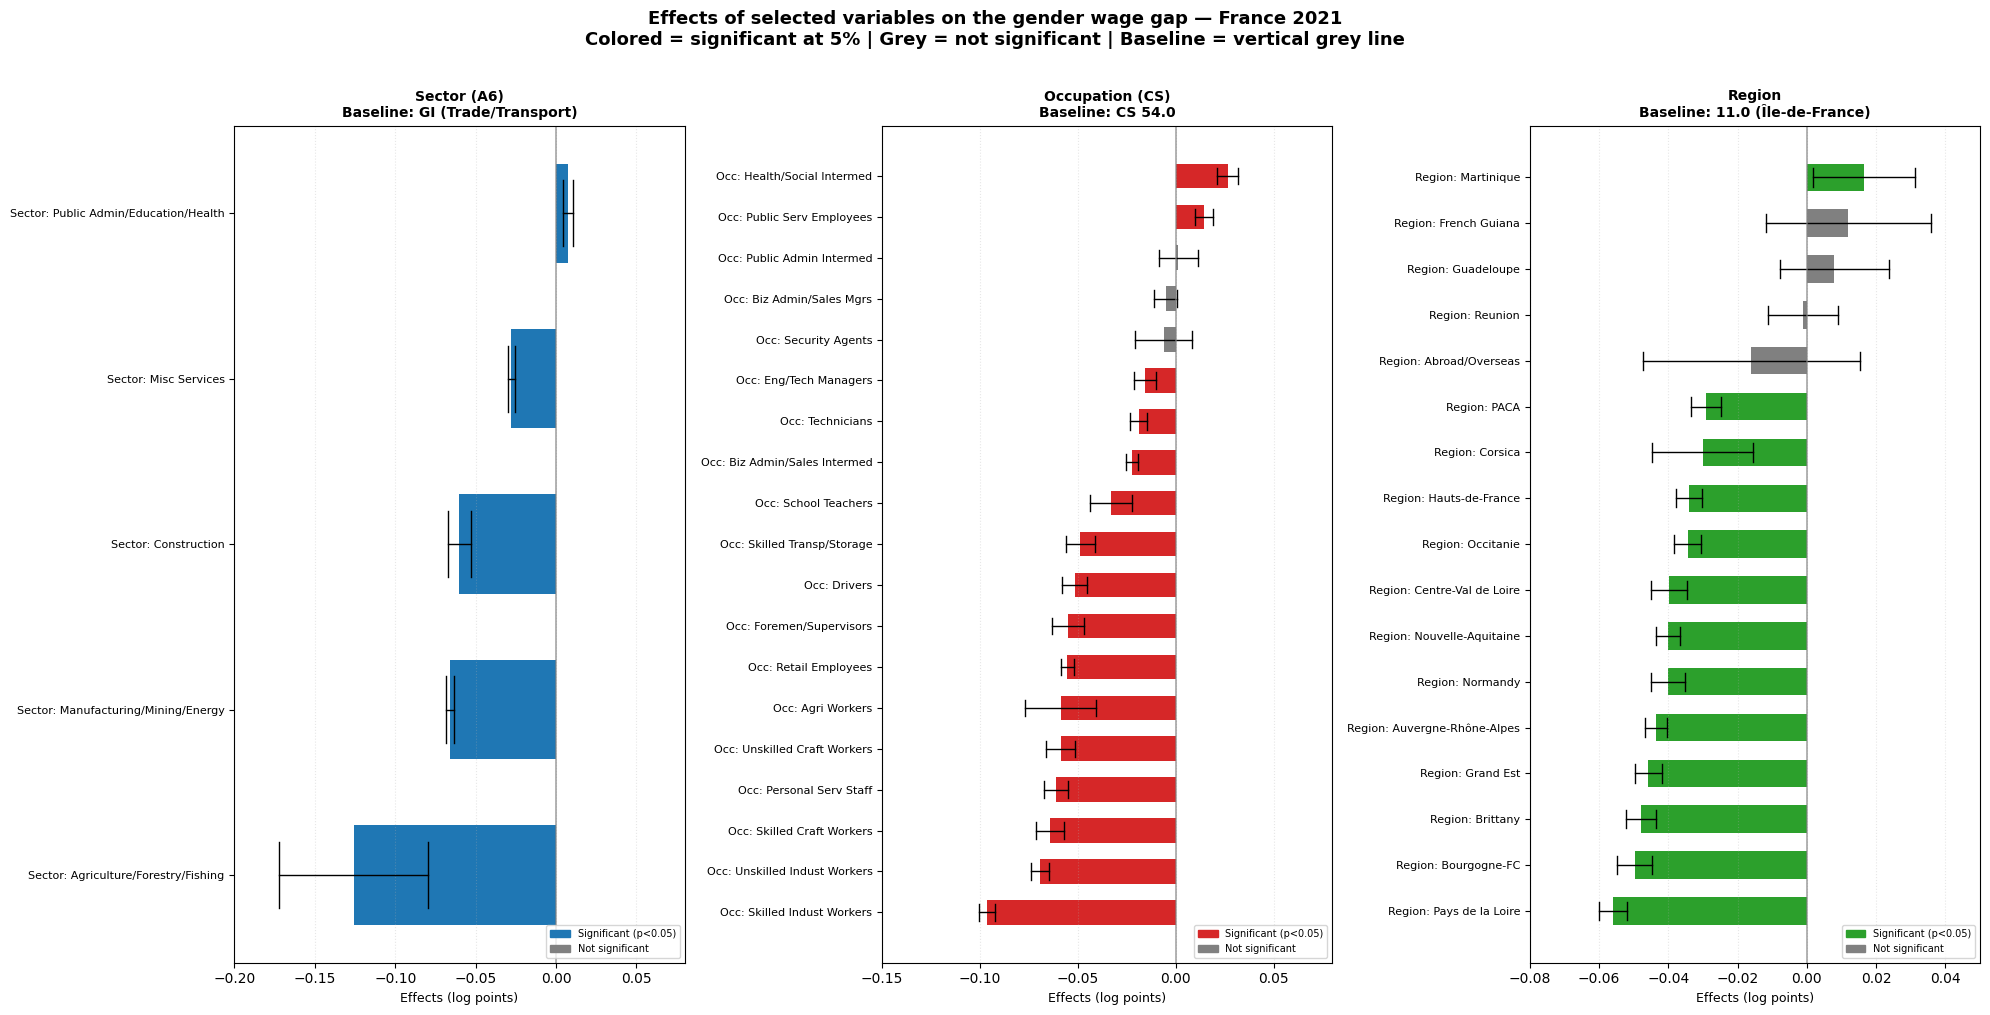

In [28]:
# ── Figure 1: Sector + Occupation + Region (horizontal) ──────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 10))

panels = [
    (s[s["group"] == "Sector (A6)"],
     "Sector (A6)\nBaseline: GI (Trade/Transport)",  "#1f77b4", (-0.20, 0.08)),
    (s[s["group"] == "Occupation (CS)"],
     "Occupation (CS)\nBaseline: CS 54.0",           "#d62728", (-0.15, 0.08)),
    (s[s["group"] == "Region"],
     "Region\nBaseline: 11.0 (Île-de-France)",       "#2ca02c", (-0.08, 0.05)),
]

for ax, (df_g, title, col, xlim) in zip(axes, panels):
    paper_style_plot(ax, df_g.copy(), title, col, xlim)

plt.suptitle(
    "Effects of selected variables on the gender wage gap — France 2021\n"
    "Colored = significant at 5% | Grey = not significant | "
    "Baseline = vertical grey line",
    fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("figure1_heterogeneity.png", dpi=150, bbox_inches="tight")
plt.show()

## Quantile Plot of Individual Gender Wage Gap Estimates
Replicates Figure 1 of Bach et al. (2021) for France 2021. Each point is one woman's estimated
gap β(xᵢ) relative to a comparable man with identical observable characteristics.

**The mean gap of -4.0% masks substantial heterogeneity** — ranging from -30% (worst-off) to +19%
(best-off women).

- **69.5% of women** earn less than a comparable man | **30.5%** have a reversed gap
- **Median: -3.5%** | p10: -13.8% | p90: +5.2%

> **Limitation:** confidence bands use rolling SD, not the simultaneous inference bands of Bach et al.
> (2021), which would require the multiplier bootstrap of Belloni et al. (2014).

Mean β(xᵢ) : -0.0404  (should be ≈ β₀ = -0.0404)
Median     : -0.0349
Min / Max  : -0.3037 / +0.1931


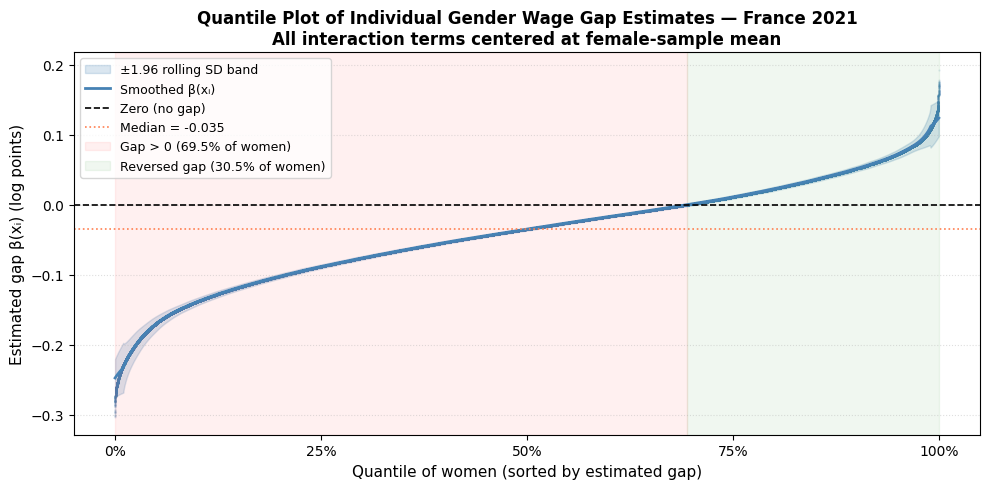

N women                  : 195,331
Gap < 0 (women earn less): 69.5%
Gap > 0 (reversed)       : 30.5%
  p10: -0.138
  p25: -0.088
  p50: -0.035
  p75: +0.011
  p90: +0.052


In [29]:
# ── Quantile plot of individual gap estimates ─────────────────────────────────
# β(xᵢ) = β₀ + Σ βⱼ · (x_ij - x̄_j)  — all terms centered at female mean

# ── Extract coefficients ──────────────────────────────────────────────────────
beta0          = summary.loc["female", "Estimate"]
interact_terms = [c for c in summary.index if c.startswith("female_X_")]
beta_j         = summary.loc[interact_terms, "Estimate"].values

# ── Subset to women & center ALL terms ───────────────────────────────────────
female_mask    = dm["female"].astype(float).values == 1
X_int_female   = X_full[interact_terms].values[female_mask]
X_int_centered = X_int_female - X_int_female.mean(axis=0)
beta_xi_f      = beta0 + X_int_centered @ beta_j

print(f"Mean β(xᵢ) : {beta_xi_f.mean():+.4f}  (should be ≈ β₀ = {beta0:+.4f})")
print(f"Median     : {np.median(beta_xi_f):+.4f}")
print(f"Min / Max  : {beta_xi_f.min():+.4f} / {beta_xi_f.max():+.4f}")

# ── Sort ──────────────────────────────────────────────────────────────────────
sort_idx    = np.argsort(beta_xi_f)
beta_sorted = beta_xi_f[sort_idx]
quantiles   = np.linspace(0, 1, len(beta_sorted))

# ── Rolling band ──────────────────────────────────────────────────────────────
window    = max(1, len(beta_sorted) // 50)
beta_s    = pd.Series(beta_sorted)
roll_mean = beta_s.rolling(window, center=True, min_periods=1).mean()
roll_std  = beta_s.rolling(window, center=True, min_periods=1).std().fillna(0)
ci_upper  = roll_mean + 1.96 * roll_std
ci_lower  = roll_mean - 1.96 * roll_std

sig_neg = beta_sorted < 0
sig_pos = beta_sorted > 0

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.fill_between(quantiles, ci_lower, ci_upper,
                alpha=0.2, color="steelblue", label="±1.96 rolling SD band")
ax.plot(quantiles, roll_mean, color="steelblue", linewidth=2,
        label="Smoothed β(xᵢ)")
ax.scatter(quantiles, beta_sorted, s=0.3, alpha=0.15, color="steelblue")
ax.axhline(0, color="black", linewidth=1.2, linestyle="--", label="Zero (no gap)")
ax.axhline(np.median(beta_sorted), color="coral", linewidth=1.2,
           linestyle=":", label=f"Median = {np.median(beta_sorted):.3f}")

if sig_neg.any():
    ax.axvspan(0, quantiles[sig_neg].max(), alpha=0.06, color="red",
               label=f"Gap > 0 ({sig_neg.mean():.1%} of women)")
if sig_pos.any():
    ax.axvspan(quantiles[sig_pos].min(), 1, alpha=0.06, color="green",
               label=f"Reversed gap ({sig_pos.mean():.1%} of women)")

ax.set_xlabel("Quantile of women (sorted by estimated gap)", fontsize=11)
ax.set_ylabel("Estimated gap β(xᵢ) (log points)", fontsize=11)
ax.set_title(
    "Quantile Plot of Individual Gender Wage Gap Estimates — France 2021\n"
    "All interaction terms centered at female-sample mean",
    fontsize=12, fontweight="bold"
)
ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_xticklabels(["0%", "25%", "50%", "75%", "100%"])
ax.legend(fontsize=9)
ax.grid(axis="y", linestyle=":", alpha=0.4)
plt.tight_layout()
plt.savefig("DB_figure_quantile_plot.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"N women                  : {female_mask.sum():,}")
print(f"Gap < 0 (women earn less): {sig_neg.mean():.1%}")
print(f"Gap > 0 (reversed)       : {sig_pos.mean():.1%}")
for q in [0.10, 0.25, 0.50, 0.75, 0.90]:
    print(f"  p{int(q*100):02d}: {np.quantile(beta_sorted, q):+.3f}")